## Deep Neural Operators

## Table of Contents
#### 1. [DeepONet for Antiderivative Operators in TF2.0](#DeepONet-for-Antiderivative-Operators-in-TF2.0)
#### 1. [DeepONet for Antiderivative Operators in JAX](#DeepONet-for-Antiderivative-Operators-in-JAX)
#### 2. [FNO for Burger's Equation](#Fourier-Neural-Operator-(FNO)-for-Burgers-Equation)

## DeepONet for Antiderivative Operators in TF2.0

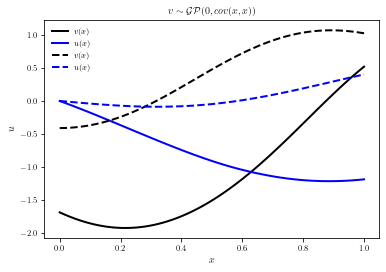

In [1]:
import tensorflow.compat as tf
import numpy as np
import scipy.io as io
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time
import scipy.io as io
import sys
sys.path.insert(0, 'Utilities/')
import os

from plotting import newfig, savefig
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec


d = np.load("antiderivative_aligned_train.npz", allow_pickle=True)
v_train, x_train, u_train = d["X"][0], d["X"][1], d["y"]

d = np.load("antiderivative_aligned_test.npz", allow_pickle=True)
v_test, x_test, u_test = d["X"][0], d["X"][1], d["y"]


####### Row 0: u(t,x) ##################    
gs0 = gridspec.GridSpec(1,1)
#gs0.update(top=1-0.06, bottom=1-1/3, left=0.15, right=0.85, wspace=0)
ax = plt.subplot(gs0[:, :])
ax.plot(x_train, v_train[10,:], '-k', lw=2.0, label="$v(x)$")
ax.plot(x_train, u_train[10,:], '-b', lw=2.0, label="$u(x)$")
ax.plot(x_train, v_test[100,:], '--k', lw=2.0, label="$v(x)$")
ax.plot(x_train, u_test[100,:], '--b', lw=2.0, label="$u(x)$")
ax.set_xlabel('$x$')
ax.set_ylabel('$u$')
ax.legend(frameon=False, loc = 'best')
ax.set_title('$v \sim \mathcal{GP}(0, cov(x,x))$', fontsize = 10)
#ax.set_xlim([0,1.2])
#ax.set_ylim([-1.1,1.1])
#ax.axis('square')
plt.savefig("Data.png", dpi=300)




In [1]:
import os
import time
import tensorflow as tf
import numpy as np
import scipy.io as io
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as io
np.random.seed(1234)
import sys

# Define a simple deep neural network helper class
class DNN:
    def __init__(self):
        # No attributes are initialized here
        pass

    # Initialize weights and biases for a fully connected neural network
    def hyper_initial(self, layers):
        L = len(layers)   # Total number of layers
        W = []            # List to store weight matrices
        b = []            # List to store bias vectors

        # Loop through each layer pair and initialize parameters
        for l in range(1, L):
            in_dim = layers[l-1]   # Input dimension of current layer
            out_dim = layers[l]    # Output dimension of current layer

            # Standard deviation based on Xavier-like initialization
            std = np.sqrt(2.0/(in_dim+out_dim))

            # Initialize weights and biases with truncated normal distribution
            weight = tf.Variable(
                tf.random.truncated_normal(shape=(in_dim, out_dim), stddev=std)
            )
            bias = tf.Variable(
                tf.random.truncated_normal(shape=(1, out_dim), stddev=std)
            )

            W.append(weight)
            b.append(bias)

        return W, b

    # Forward pass for the Branch network
    def fnn_B(self, X, W, b):
        A = X
        A = tf.cast(A, dtype=tf.float32)  # Ensure input is float32
        L = len(W)

        # Apply hidden layers with tanh activation
        for i in range(L-1):
            A = tf.tanh(tf.add(tf.matmul(A, W[i]), b[i]))

        # Final output layer without activation
        Y = tf.add(tf.matmul(A, W[-1]), b[-1])
        return Y

    # Forward pass for the Trunk network
    def fnn_T(self, X, W, b):
        A = X  # Input normalization could be applied here if needed
        A = tf.cast(A, dtype=tf.float32)  # Ensure input is float32
        L = len(W)

        # Apply hidden layers with tanh activation
        for i in range(L-1):
            A = tf.tanh(tf.add(tf.matmul(A, W[i]), b[i]))

        # Final output layer without activation
        Y = tf.add(tf.matmul(A, W[-1]), b[-1])
        return Y


# =========================
# Load training data
# =========================
d = np.load("antiderivative_aligned_train.npz", allow_pickle=True)
v_train, x_train, u_train = d["X"][0], d["X"][1], d["y"]

# Load test data
d = np.load("antiderivative_aligned_test.npz", allow_pickle=True)
v_test, x_test, u_test = d["X"][0], d["X"][1], d["y"]

# Input dimension for Branch network
u_dim = 100

# Shared latent output dimension for Branch and Trunk networks
G_dim = 100

# Branch network architecture: input -> 2 hidden layers -> output
layers_f = [u_dim] + [40]*2 + [G_dim]

# Input dimension for Trunk network
x_dim = 1

# Trunk network architecture: input -> 2 hidden layers -> output
layers_x = [x_dim] + [40]*2 + [G_dim]

# Create model instance
model = DNN()


# Single training step
def train_step(model, W_branch, b_branch, W_trunk, b_trunk, v, x, u, opt):
    # Collect all trainable variables
    train_vars = W_branch + b_branch + W_trunk + b_trunk

    with tf.GradientTape() as tape:
        # Watch trainable variables for automatic differentiation
        tape.watch([W_branch, b_branch, W_trunk, b_trunk])

        # Forward pass through Branch and Trunk networks
        u_out_branch = model.fnn_B(v, W_branch, b_branch)
        u_out_trunk = model.fnn_T(x, W_trunk, b_trunk)

        # Combine Branch and Trunk outputs using einsum
        # Produces operator output prediction
        u_pred = tf.einsum('ij,kj->ik', u_out_branch, u_out_trunk)

        # Mean squared error loss
        loss = tf.reduce_mean(tf.square(u_pred - u))

    # Compute gradients and update parameters
    grads = tape.gradient(loss, train_vars)
    opt.apply_gradients(zip(grads, train_vars))

    return loss, u_pred


# Single test/evaluation step
def test_step(model, W_branch, b_branch, W_trunk, b_trunk, v, x, u, opt):
    # Convert numpy arrays to TensorFlow tensors
    x_test_tf = tf.convert_to_tensor(x, dtype=tf.float32)
    v_test_tf = tf.convert_to_tensor(v, dtype=tf.float32)
    u_test_tf = tf.convert_to_tensor(u, dtype=tf.float32)

    # Forward pass through Branch and Trunk networks
    u_out_branch = model.fnn_B(v_test_tf, W_branch, b_branch)
    u_out_trunk = model.fnn_T(x_test_tf, W_trunk, b_trunk)

    # Combine outputs to form prediction
    u_pred = tf.einsum('ij,kj->ik', u_out_branch, u_out_trunk)

    # Mean squared error loss
    loss = tf.reduce_mean(tf.square(u_pred - u))

    return loss, u_pred


# Initialize Branch and Trunk network parameters
W_branch, b_branch = model.hyper_initial(layers_f)
W_trunk, b_trunk = model.hyper_initial(layers_x)

# Training configuration
n = 0
nmax = 10000
lr = 5e-4

# Track timing
start_time = time.perf_counter()
time_step_0 = time.perf_counter()

# Adam optimizer
optimizer = tf.optimizers.Adam(learning_rate=lr)

# Lists to store errors and losses during training
train_err_list = []
test_err_list = []
train_loss_list = []
test_loss_list = []

# =========================
# Training loop
# =========================
while n <= nmax:
    # Convert training data to TensorFlow tensors
    x_train_tf = tf.convert_to_tensor(x_train, dtype=tf.float32)
    v_train_tf = tf.convert_to_tensor(v_train, dtype=tf.float32)
    u_train_tf = tf.convert_to_tensor(u_train, dtype=tf.float32)

    # Perform one training step
    loss_train, u_train_pred = train_step(
        model, W_branch, b_branch, W_trunk,
        b_trunk, v_train_tf, x_train_tf, u_train_tf,
        optimizer
    )

    # Compute relative L2 training error
    err_train = np.mean(
        np.linalg.norm(u_train - u_train_pred, 2, axis=1) /
        np.linalg.norm(u_train, 2, axis=1)
    )

    # Perform one test step
    loss_test, u_test_pred = test_step(
        model, W_branch, b_branch, W_trunk, b_trunk,
        v_test, x_test, u_test, optimizer
    )

    # Compute relative L2 test error
    err_test = np.mean(
        np.linalg.norm(u_test - u_test_pred, 2, axis=1) /
        np.linalg.norm(u_test, 2, axis=1)
    )

    # Print progress every 100 iterations
    if n % 500 == 0:
        print(f"Iteration: {n} Train_loss:{loss_train}, Test_loss: {loss_test}")

    # Store metrics
    train_err_list.append(err_train)
    test_err_list.append(err_test)
    train_loss_list.append(loss_train)
    test_loss_list.append(loss_test)

    # Increment iteration counter
    n = n + 1

2026-04-05 14:42:01.962070: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Iteration: 0 Train_loss:1.164702296257019, Test_loss: 0.7112268805503845
Iteration: 500 Train_loss:0.0036528059281408787, Test_loss: 0.004333720076829195
Iteration: 1000 Train_loss:0.0006665444234386086, Test_loss: 0.0013702231226488948
Iteration: 1500 Train_loss:0.0004679509438574314, Test_loss: 0.0009019886492751539
Iteration: 2000 Train_loss:0.0004140324890613556, Test_loss: 0.0007460119668394327
Iteration: 2500 Train_loss:0.00040836085099726915, Test_loss: 0.0007952831801958382
Iteration: 3000 Train_loss:0.0003427915507927537, Test_loss: 0.0005926918238401413
Iteration: 3500 Train_loss:0.00037830579094588757, Test_loss: 0.0006330169853754342
Iteration: 4000 Train_loss:0.0003112110716756433, Test_loss: 0.0005067962920293212
Iteration: 4500 Train_loss:0.0008757939212955534, Test_loss: 0.0006426676991395652
Iteration: 5000 Train_loss:0.0002736809547059238, Test_loss: 0.0004433854774106294
Iteration: 5500 Train_loss:0.00021838922111783177, Test_loss: 0.0003966727526858449
Iteration: 60

Iteration: 9900 Train_loss:2.9126973458915018e-05, Test_loss: 0.00012926151975989342
Iteration: 10000 Train_loss:3.273977927165106e-05, Test_loss: 0.00012896307453047484


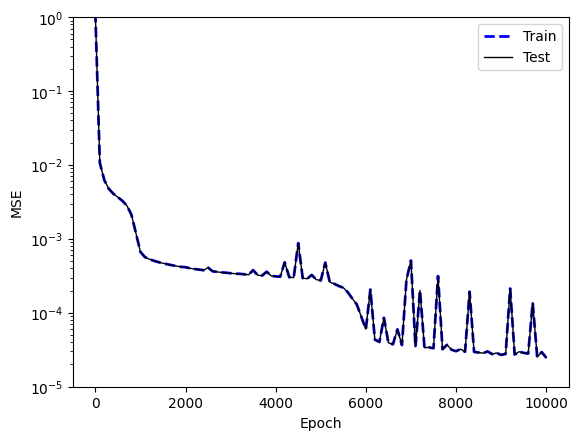

In [2]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


train_loss = np.array(train_loss_list)
test_loss =  np.array(test_loss_list)
plot_int = 100

ep = np.arange(0,nmax+1,1)
ep = ep[::plot_int]

train_loss_plot = train_loss[::plot_int]
test_loss_plot = train_loss[::plot_int]



gs = gridspec.GridSpec(1,1)
ax = plt.subplot(gs[:, :])
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.set_ylim([10**-5, 1])
ax.semilogy(ep, train_loss_plot, '--b', lw=2.0, label="Train")
ax.semilogy(ep, test_loss_plot, '-k', lw=1.0, label="Test")
plt.legend()
plt.savefig("Loss.png", dpi=300)
plt.show()




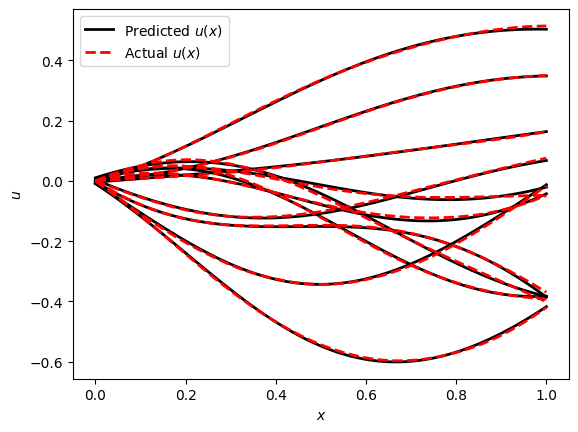

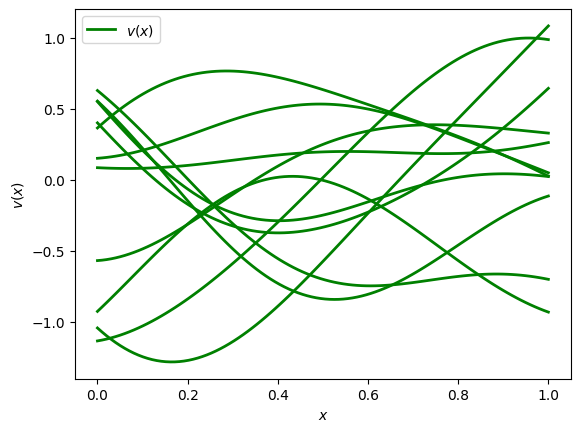

In [3]:
####
gs1 = gridspec.GridSpec(1,1)
ax1 = plt.subplot(gs1[:, :])

ax1.plot(x_test, u_test_pred[20, :], '-k', lw=2.0, label="Predicted $u(x)$")

for i in range(10,20):
    ax1.plot(x_test, u_test_pred[i, :], '-k', lw=2.0)

ax1.plot(x_test, u_test[20, :], '--r', lw=2.0, label="Actual $u(x)$")

for i in range(10,20):
    ax1.plot(x_train,u_test[i, :], '--r', lw=2.0)



ax1.set_xlabel('$x$')
ax1.set_ylabel('$u$')
ax1.legend(frameon=True, loc = 'best')
plt.savefig("predicted_and_deeponet.png", dpi=300)
plt.show()

####
gs2 = gridspec.GridSpec(1,1)
ax2 = plt.subplot(gs2[:, :])

ax2.plot(x_test, v_test[20, :], '-g', lw=2.0, label="$v(x)$")
for i in range(10,20):
    ax2.plot(x_test, v_test[i, :], '-g', lw=2.0)

ax2.set_xlabel('$x$')
ax2.set_ylabel('$v(x)$')
ax2.legend(frameon=True, loc = 'best')
plt.savefig("forcing.png", dpi=300)

## PI-DeepONet for Antiderivative Operators in TF

In [6]:
import os
import time
import tensorflow as tf
import numpy as np
import scipy.io as io
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as io
np.random.seed(1234)
import sys

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 


class DNN:
    def __init__(self):
        pass
    #initialization for DNNs
    def hyper_initial(self, layers):
        L = len(layers)
        W = []
        b = []
        for l in range(1, L):
            in_dim = layers[l-1]
            out_dim = layers[l]
            std = np.sqrt(2.0/(in_dim+out_dim))
            weight = tf.Variable(tf.random.truncated_normal(shape=(in_dim, out_dim), stddev = std))
            bias = tf.Variable(tf.random.truncated_normal(shape=(1, out_dim), stddev = std))
            W.append(weight)
            b.append(bias)
        return W, b

    def fnn_B(self, X, W, b):
        A = X
        A = tf.cast(A, dtype=tf.float32)
        L = len(W)
        for i in range(L-1):
            A = tf.nn.relu(tf.add(tf.matmul(A, W[i]), b[i]))
        Y = tf.add(tf.matmul(A, W[-1]), b[-1])
        return Y
    
    def fnn_T(self, X, W, b):
        A = X #2.*(X - Xmin)/(Xmax - Xmin) - 1.0
        A = tf.cast(A, dtype=tf.float32)
        L = len(W)
        for i in range(L-1):
            A = tf.tanh(tf.add(tf.matmul(A, W[i]), b[i]))
        Y = tf.add(tf.matmul(A, W[-1]), b[-1])
        return Y
    
    
#Load Training Data
d = np.load("antiderivative_aligned_train.npz", allow_pickle=True)
v_train, x_train, u_train = d["X"][0], d["X"][1], d["y"]


d = np.load("antiderivative_aligned_test.npz", allow_pickle=True)
v_test, x_test, u_test = d["X"][0], d["X"][1], d["y"]

#input dimension for Branch Net
u_dim = 100

#output dimension for Branch and Trunk Net
G_dim = 100

#Branch Net
layers_f = [u_dim] + [40]*4 + [G_dim]

# Trunk dim
x_dim = 1

#Trunk Net
layers_x = [x_dim] + [40]*4 + [G_dim]

model = DNN()

@tf.function()
def train_step(model, W_branch, b_branch, W_trunk, b_trunk, v, x, u, opt):
    train_vars = W_branch + b_branch + W_trunk + b_trunk
    with tf.GradientTape(persistent=True) as tape:
        tape.watch([W_branch, b_branch, W_trunk, b_trunk, x])
        u_out_branch = model.fnn_B(v, W_branch, b_branch)
        u_out_trunk = model.fnn_T(x, W_trunk, b_trunk)       
        u_pred = tf.einsum('ij,kj->ik', u_out_branch, u_out_trunk)
        loss_data = tf.reduce_mean(tf.square(u_pred - u))        
        loss_phys = 0.0
        #print(tf.shape(v))
        for i in range(0, 10):      
            u_p = u_pred[i]
            u_o = v[i]
            res = tape.gradient(u_p, x)
            loss_phys += tf.reduce_mean(tf.square(res - u_o))
            loss = loss_phys + loss_data
        grads = tape.gradient(loss, train_vars)
        opt.apply_gradients(zip(grads, train_vars))
        return loss_data, u_pred 

def test_step(model, W_branch, b_branch, W_trunk, b_trunk, v, x, u, opt):
    x_test_tf = tf.convert_to_tensor(x, dtype=tf.float32)
    v_test_tf = tf.convert_to_tensor(v, dtype=tf.float32)
    u_test_tf = tf.convert_to_tensor(u, dtype=tf.float32)
    u_out_branch = model.fnn_B(v_test_tf, W_branch, b_branch)
    u_out_trunk = model.fnn_T(x_test_tf, W_trunk, b_trunk)       
    u_pred = tf.einsum('ij,kj->ik', u_out_branch, u_out_trunk)
    loss = tf.reduce_mean(tf.square(u_pred - u))        
    return loss, u_pred 

    
W_branch, b_branch = model.hyper_initial(layers_f)
W_trunk, b_trunk =   model.hyper_initial(layers_x)

n = 0
nmax = 10000
lr = 1e-4
start_time = time.time()
time_step_0 = time.time()
optimizer = tf.optimizers.Adam(learning_rate=lr)
                        
train_err_list = []
test_err_list = []
train_loss_list = []
test_loss_list = []

while n <= nmax:
    x_train_tf = tf.convert_to_tensor(x_train, dtype=tf.float32)
    v_train_tf = tf.convert_to_tensor(v_train, dtype=tf.float32)
    u_train_tf = tf.convert_to_tensor(u_train, dtype=tf.float32)
    loss_train, u_train_pred = train_step(model, W_branch, b_branch, W_trunk, \
                                          b_trunk, v_train_tf, x_train_tf, u_train_tf, \
                            optimizer)
    err_train = np.mean(np.linalg.norm(u_train - u_train_pred, 2, axis=1)/\
                np.linalg.norm(u_train , 2, axis=1))
    
    loss_test, u_test_pred = test_step(model, W_branch, b_branch, W_trunk, b_trunk, v_test, x_test, u_test, \
                            optimizer)
    err_test = np.mean(np.linalg.norm(u_test - u_test_pred, 2, axis=1)/\
            np.linalg.norm(u_test , 2, axis=1))
    
    if n % 100 == 0:
        print(f"Iteration: {n} Train_loss:{loss_train}, Test_loss: {loss_test}")
    train_err_list.append(err_train)
    test_err_list.append(err_test)
    train_loss_list.append(loss_train)
    test_loss_list.append(loss_test)     
    n = n + 1

    


Iteration: 0 Train_loss:0.3647967576980591, Test_loss: 0.40203890204429626
Iteration: 100 Train_loss:0.020022425800561905, Test_loss: 0.019341889768838882
Iteration: 200 Train_loss:0.010449131950736046, Test_loss: 0.010220623575150967
Iteration: 300 Train_loss:0.00825316458940506, Test_loss: 0.008423537947237492
Iteration: 400 Train_loss:0.0068852873519063, Test_loss: 0.00726036261767149
Iteration: 500 Train_loss:0.005405094474554062, Test_loss: 0.006238591857254505
Iteration: 600 Train_loss:0.0050542401149868965, Test_loss: 0.005798559170216322
Iteration: 700 Train_loss:0.004836104344576597, Test_loss: 0.00553868105635047
Iteration: 800 Train_loss:0.004669958725571632, Test_loss: 0.005336014553904533
Iteration: 900 Train_loss:0.0045580738224089146, Test_loss: 0.005171091295778751
Iteration: 1000 Train_loss:0.004473668523132801, Test_loss: 0.005056350491940975
Iteration: 1100 Train_loss:0.004407088737934828, Test_loss: 0.004964787513017654
Iteration: 1200 Train_loss:0.00435015140101313

Iteration: 9600 Train_loss:0.0008017286891117692, Test_loss: 0.0013025576481595635
Iteration: 9700 Train_loss:0.0007726604235358536, Test_loss: 0.0012777552474290133
Iteration: 9800 Train_loss:0.0007674226071685553, Test_loss: 0.0012693910393863916
Iteration: 9900 Train_loss:0.0007592600886709988, Test_loss: 0.0012577340239658952
Iteration: 10000 Train_loss:0.000753051892388612, Test_loss: 0.001249820226803422


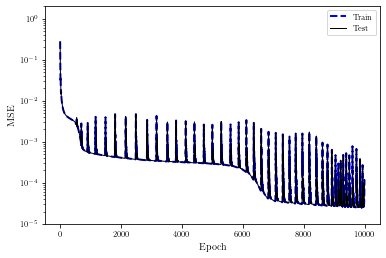

In [3]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


train_loss = np.array(train_loss_list)
test_loss =  np.array(test_loss_list)
plot_int = 1

ep = np.arange(0,nmax+1,1)
ep = ep[::plot_int]

train_loss_plot = train_loss[::plot_int]
test_loss_plot = train_loss[::plot_int]



gs = gridspec.GridSpec(1,1)
ax = plt.subplot(gs[:, :])
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.set_ylim([10**-5, 2])
ax.semilogy(ep, train_loss_plot, '--b', lw=2.0, label="Train")
ax.semilogy(ep, test_loss_plot, '-k', lw=1.0, label="Test")
plt.legend()
plt.savefig("Loss.png", dpi=300)
plt.show()



## DeepONet for Antiderivative Operators in JAX

In [8]:
import jax
import numpy as np
import jax.numpy as jnp
import optax
from jax.example_libraries import optimizers
from jax import jit, grad, vmap, value_and_grad
from jax import random
import scipy.io as io
import time
import sys
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec


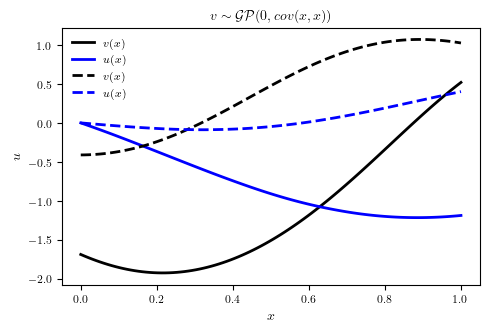

In [10]:
import numpy as np
import jax.numpy as jnp
# Load the data and visualize 
d = np.load("antiderivative_train.npz", allow_pickle=True)
v_train, x_train, u_train = jnp.array(d["X"][0]), \
jnp.array(d["X"][1]), jnp.array(d["y"])

d = np.load("antiderivative_test.npz", allow_pickle=True)
v_test, x_test, u_test = jnp.array(d["X"][0]),\
jnp.array(d["X"][1]), jnp.array(d["y"])

####### Row 0: u(t,x) ##################    
gs0 = gridspec.GridSpec(1,1)
ax = plt.subplot(gs0[:, :])
ax.plot(x_train, v_train[10,:], '-k', lw=2.0, label="$v(x)$")
ax.plot(x_train, u_train[10,:], '-b', lw=2.0, label="$u(x)$")
ax.plot(x_train, v_test[100,:], '--k', lw=2.0, label="$v(x)$")
ax.plot(x_train, u_test[100,:], '--b', lw=2.0, label="$u(x)$")
ax.set_xlabel('$x$')
ax.set_ylabel('$u$')
ax.legend(frameon=False, loc = 'best')
ax.set_title('$v \sim \mathcal{GP}(0, cov(x,x))$', fontsize = 10)
plt.savefig("Data.png", dpi=300)
plt.show()

In [9]:
key = random.PRNGKey(1234)
initializer = jax.nn.initializers.glorot_normal()
def hyper_initial(layers):
    L = len(layers)
    W = []
    b = []
    for l in range(1, L):
        in_dim = layers[l-1]
        out_dim = layers[l]
        std = np.sqrt(2.0/(in_dim+out_dim))
        weight = initializer(key, (in_dim, out_dim), jnp.float32)*std
        bias = initializer(key, (1, out_dim), jnp.float32)*std
        W.append(weight)
        b.append(bias)
    return W, b
def fnn_B(X, W, b):
    inputs = X
    L = len(W)
    for i in range(L-1):
        outputs = jnp.dot(inputs, W[i]) + b[i]
        inputs = jnp.tanh(outputs)  
    Y = jnp.dot(inputs, W[-1]) + b[-1]     
    return Y

def fnn_T(X, W, b):
    inputs = X
    L = len(W)
    for i in range(L-1):
        outputs = jnp.dot(inputs, W[i]) + b[i]
        inputs = jnp.tanh(outputs)  # inputs to the next layer
    Y = jnp.dot(inputs, W[-1]) + b[-1]     
    return Y


def predict(params, data):
    W_branch, b_branch, W_trunk, b_trunk = params
    v, x = data
    u_out_branch = fnn_B(v, W_branch, b_branch) # predict on branch
    u_out_trunk = fnn_T(x, W_trunk, b_trunk) # predict on trunk
    u_pred = jnp.einsum('ik,jk->ik',u_out_branch, u_out_trunk) # matmul
    return u_pred

def loss(params, data, u):
    u_preds = predict(params, data)
    # print(u_preds)
    mse = jnp.mean(jnp.sum((u_preds - u)**2, axis = 1)) 
    # print(mse)
    return mse

@jit
def update(params, data, u, opt_state):
    """ Compute the gradient for a batch and update the parameters """
    value, grads = value_and_grad(loss)(params, data, u)
    opt_state = opt_update(0, grads, opt_state)
    return get_params(opt_state), opt_state, value


#input dimension for Branch Net
u_dim = 100
#output dimension for Branch and Trunk Net
G_dim = 100
#Branch Net
layers_f = [u_dim] + [40]*2 + [G_dim]
# Trunk dim
x_dim = 1
#Trunk Net
layers_x = [x_dim] + [40]*2 + [G_dim]
W_branch, b_branch = hyper_initial(layers_f)
W_trunk, b_trunk =   hyper_initial(layers_x)
# Defining an optimizer in Jax
num_epochs = 10000
lr = 5e-4
opt_init, opt_update, get_params = optimizers.adam(lr)
opt_state = opt_init([W_branch, b_branch, W_trunk, b_trunk])
params = get_params(opt_state)
train_loss, test_loss = [], []

start_time = time.time()

for epoch in range(num_epochs):
    params, opt_state, loss_val = update(params, [v_train, x_train], u_train, opt_state)
    train_loss.append(loss_val)
    if epoch % 100 ==0:
        epoch_time = time.time() - start_time
        u_train_pred = predict(params, [v_train, x_train])
        err_train = jnp.mean(jnp.linalg.norm(u_train - u_train_pred, 2, axis=1)/\
                             np.linalg.norm(u_train , 2, axis=1))
        u_test_pred = predict(params, [v_test, x_test])
        err_test = jnp.mean(jnp.linalg.norm(u_test - u_test_pred, 2, axis=1)/\
                            np.linalg.norm(u_test , 2, axis=1))
        test_loss_val = loss(params, [v_test, x_test], u_test)
        test_loss.append(test_loss_val)
        print("Epoch {} | T: {:0.6f} | Train MSE: {:0.4f} | \
        Test MSE: {:0.4f} | Train L2: {:0.4f} | Test L2: {:0.4f}"\
              .format(epoch, epoch_time, loss_val, test_loss_val, err_train, err_test))

NameError: name 'random' is not defined

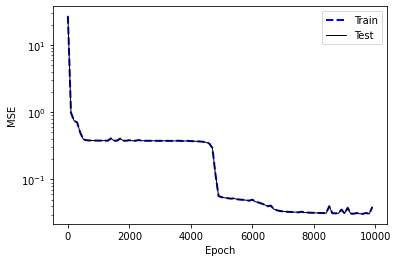

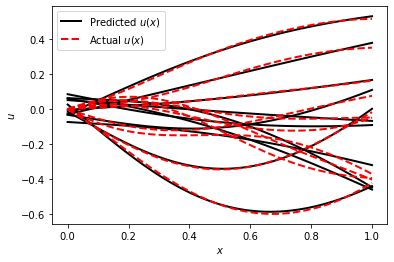

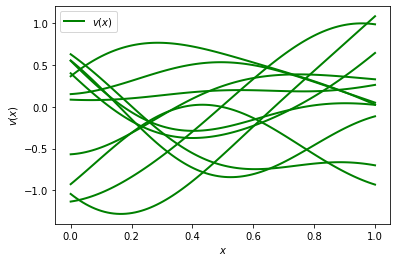

In [5]:
train_loss = np.array(train_loss)
test_loss =  np.array(test_loss)
plot_int = 100

ep = np.arange(0,num_epochs,1)
ep = ep[::plot_int]

train_loss_plot = train_loss[::plot_int]
test_loss_plot = train_loss[::plot_int]



gs = gridspec.GridSpec(1,1)
ax = plt.subplot(gs[:, :])
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
#ax.set_ylim([10**-5, 1])
ax.semilogy(ep, train_loss_plot, '--b', lw=2.0, label="Train")
ax.semilogy(ep, test_loss_plot, '-k', lw=1.0, label="Test")
plt.legend()
plt.savefig("Loss.png", dpi=300)
plt.show()



pred = predict(params, [v_train, x_train])
u_test_pred = predict(params, [v_test, x_test])

############################
gs1 = gridspec.GridSpec(1,1)
ax1 = plt.subplot(gs1[:, :])

ax1.plot(x_test, u_test_pred[20, :], '-k', lw=2.0, label="Predicted $u(x)$")

for i in range(10,20):
    ax1.plot(x_test, u_test_pred[i, :], '-k', lw=2.0)

ax1.plot(x_test, u_test[20, :], '--r', lw=2.0, label="Actual $u(x)$")

for i in range(10,20):
    ax1.plot(x_train,u_test[i, :], '--r', lw=2.0)



ax1.set_xlabel('$x$')
ax1.set_ylabel('$u$')
ax1.legend(frameon=True, loc = 'best')
plt.savefig("predicted_and_deeponet.png", dpi=300)
plt.show()

####
gs2 = gridspec.GridSpec(1,1)
ax2 = plt.subplot(gs2[:, :])

ax2.plot(x_test, v_test[20, :], '-g', lw=2.0, label="$v(x)$")
for i in range(10,20):
    ax2.plot(x_test, v_test[i, :], '-g', lw=2.0)

ax2.set_xlabel('$x$')
ax2.set_ylabel('$v(x)$')
ax2.legend(frameon=True, loc = 'best')
plt.savefig("forcing.png", dpi=300)

## Fourier Neural Operator (FNO) for Burgers Equation

In [ ]:
# ============================================================
# Fourier Neural Operator (FNO) for 1D Burgers equation
# Original code note in file: "Z Li (2020) is original code"
# Heavily Modified and commented version
# ============================================================

# -----------------------------
# Standard numerical libraries
# -----------------------------
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# PyTorch core
# -----------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.parameter import Parameter

# -----------------------------
# Utility imports
# -----------------------------
import operator
from functools import reduce
from functools import partial
from timeit import default_timer

# Custom helper functions/classes.
# Likely includes:
# - MatReader: for loading .mat datasets
# - count_params: for parameter counting
# - LpLoss: relative Lp loss used in operator learning
from op_utilities import *

# Adam optimizer
from torch.optim import Adam

# -----------------------------
# Fix random seeds for reproducibility
# -----------------------------
torch.manual_seed(0)
np.random.seed(0)


# ============================================================
# Spectral convolution layer in 1D
# ============================================================
# This is the key building block of the FNO.
# Instead of doing a local convolution in physical space,
# it:
#   1. transforms the signal to Fourier space,
#   2. multiplies only a limited number of low-frequency modes,
#   3. transforms back to physical space.
#
# This lets the network learn global integral operators efficiently.
# ============================================================
class SpectralConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1):
        super(SpectralConv1d, self).__init__()

        # Number of input channels/features
        self.in_channels = in_channels

        # Number of output channels/features
        self.out_channels = out_channels

        # Number of Fourier modes to keep and learn.
        # For a real 1D FFT, the total number of available frequencies
        # after rfft is floor(N/2)+1.
        # We only learn the first "modes1" low-frequency modes.
        self.modes1 = modes1

        # Scaling factor for weight initialization.
        # Keeps initial values small and stable.
        self.scale = (1 / (in_channels * out_channels))

        # Learnable complex-valued weights in Fourier space.
        # Shape:
        #   (in_channels, out_channels, modes1)
        #
        # Each retained Fourier mode gets its own learned transformation
        # from input channels to output channels.
        self.weights1 = nn.Parameter(
            self.scale * torch.rand(
                in_channels,
                out_channels,
                self.modes1,
                dtype=torch.cfloat
            )
        )

    # --------------------------------------------------------
    # Complex multiplication in Fourier space
    # --------------------------------------------------------
    # input shape:   (batch, in_channel, x_modes)
    # weights shape: (in_channel, out_channel, x_modes)
    # output shape:  (batch, out_channel, x_modes)
    #
    # This mixes channels independently at each retained frequency.
    # --------------------------------------------------------
    def compl_mul1d(self, input, weights):
        return torch.einsum("bix,iox->box", input, weights)

    # --------------------------------------------------------
    # Forward pass of spectral convolution
    # --------------------------------------------------------
    def forward(self, x):
        # x shape:
        #   (batch, in_channels, spatial_points)
        batchsize = x.shape[0]

        # Compute 1D real FFT along the spatial dimension.
        # Output is complex-valued and only contains nonnegative frequencies.
        # Shape:
        #   (batch, in_channels, N//2 + 1)
        x_ft = torch.fft.rfft(x)

        # Prepare output tensor in Fourier space.
        # It has the frequency resolution corresponding to rfft output.
        out_ft = torch.zeros(
            batchsize,
            self.out_channels,
            x.size(-1)//2 + 1,
            device=x.device,
            dtype=torch.cfloat
        )

        # Only the first "modes1" Fourier modes are learned/transformed.
        # Higher frequencies are left as zero.
        #
        # This is a low-pass spectral operator:
        # the model focuses on dominant, smooth structures.
        out_ft[:, :, :self.modes1] = self.compl_mul1d(
            x_ft[:, :, :self.modes1],
            self.weights1
        )

        # Transform back to physical space using inverse real FFT.
        # Result shape:
        #   (batch, out_channels, spatial_points)
        x = torch.fft.irfft(out_ft, n=x.size(-1))
        return x


# ============================================================
# 1D Fourier Neural Operator model
# ============================================================
# This network learns a mapping:
#   input function a(x) --> output function u(x)
#
# For Burgers equation, a(x) may be an initial condition or coefficient,
# and u(x) is the target solution/function.
#
# Structure:
#   1. Lift input to higher-dimensional feature space
#   2. Apply several Fourier layers + local skip layers
#   3. Project back to scalar output
# ============================================================
class FNO1d(nn.Module):
    def __init__(self, modes, width):
        super(FNO1d, self).__init__()

        # Number of retained Fourier modes in each spectral layer
        self.modes1 = modes

        # Width of hidden feature channels
        self.width = width

        # Optional padding value.
        # In some FNO implementations, padding is used when data is not periodic.
        # Here it is defined but not actually used in forward().
        self.padding = 2

        # First linear layer ("lifting layer")
        # Input channel dimension is 2:
        #   - the field value a(x)
        #   - the coordinate x itself
        #
        # So each spatial point has a 2D feature vector: [a(x), x]
        self.fc0 = nn.Linear(2, self.width)

        # Four spectral convolution layers
        self.conv0 = SpectralConv1d(self.width, self.width, self.modes1)
        self.conv1 = SpectralConv1d(self.width, self.width, self.modes1)
        self.conv2 = SpectralConv1d(self.width, self.width, self.modes1)
        self.conv3 = SpectralConv1d(self.width, self.width, self.modes1)

        # Four 1x1 convolutions
        # These act like pointwise linear transformations across channels.
        # They provide a local path that complements the global Fourier path.
        self.w0 = nn.Conv1d(self.width, self.width, 1)
        self.w1 = nn.Conv1d(self.width, self.width, 1)
        self.w2 = nn.Conv1d(self.width, self.width, 1)
        self.w3 = nn.Conv1d(self.width, self.width, 1)

        # Projection head:
        # hidden features -> 128 -> scalar output at each spatial location
        self.fc1 = nn.Linear(self.width, 128)
        self.fc2 = nn.Linear(128, 1)

    # --------------------------------------------------------
    # Forward pass
    # --------------------------------------------------------
    def forward(self, x):
        # Input x shape:
        #   (batch, spatial_points, 1)
        # where the last dimension is the scalar field a(x)

        # Build coordinate grid and concatenate it to the input.
        # This makes the model coordinate-aware.
        grid = self.get_grid(x.shape, x.device)

        # Concatenate along feature dimension:
        # from (batch, s, 1) to (batch, s, 2)
        x = torch.cat((x, grid), dim=-1)

        # Lift input features into higher-dimensional channel space
        # Shape becomes:
        #   (batch, s, width)
        x = self.fc0(x)

        # Rearrange for Conv1d / spectral conv format:
        #   (batch, channels, spatial_points)
        x = x.permute(0, 2, 1)

        # -------------------------
        # Fourier block 1
        # -------------------------
        # x1: global spectral operator
        x1 = self.conv0(x)

        # x2: local pointwise linear operator
        x2 = self.w0(x)

        # Combine global and local information
        x = x1 + x2

        # Nonlinear activation
        x = F.gelu(x)

        # -------------------------
        # Fourier block 2
        # -------------------------
        x1 = self.conv1(x)
        x2 = self.w1(x)
        x = x1 + x2
        x = F.gelu(x)

        # -------------------------
        # Fourier block 3
        # -------------------------
        x1 = self.conv2(x)
        x2 = self.w2(x)
        x = x1 + x2
        x = F.gelu(x)

        # -------------------------
        # Fourier block 4
        # -------------------------
        # Final block has no GELU after it in this implementation
        x1 = self.conv3(x)
        x2 = self.w3(x)
        x = x1 + x2

        # Convert back to:
        #   (batch, spatial_points, channels)
        x = x.permute(0, 2, 1)

        # Projection to lower-dimensional hidden space
        x = self.fc1(x)
        x = F.gelu(x)

        # Final scalar output at each point
        # Output shape:
        #   (batch, spatial_points, 1)
        x = self.fc2(x)
        return x

    # --------------------------------------------------------
    # Create spatial coordinate grid
    # --------------------------------------------------------
    # This gives each spatial point its x-location in [0,1].
    # The grid is concatenated with the input function values.
    #
    # shape is expected to look like:
    #   (batchsize, size_x, channels)
    # --------------------------------------------------------
    def get_grid(self, shape, device):
        batchsize, size_x = shape[0], shape[1]

        # Create 1D coordinate values from 0 to 1
        gridx = torch.tensor(np.linspace(0, 1, size_x), dtype=torch.float)

        # Reshape to (1, size_x, 1) and repeat for the whole batch
        gridx = gridx.reshape(1, size_x, 1).repeat([batchsize, 1, 1])

        return gridx.to(device)


# ============================================================
# Configuration / hyperparameters
# ============================================================

# Number of training samples
ntrain = 1000

# Number of test samples
ntest = 100

# Subsampling rate:
# original resolution is downsampled by factor 2^3 = 8
sub = 2**3

# Effective spatial grid size after subsampling
# Original size appears to be 2^13 = 8192
# After downsampling: 8192 / 8 = 1024
h = 2**13 // sub

# Spatial resolution used by the model
s = h

# Batch size for training/testing
batch_size = 20

# Initial learning rate
learning_rate = 0.001

# Number of training epochs
epochs = 500

# Learning-rate scheduler settings:
# every 50 epochs, lr is multiplied by gamma = 0.5
step_size = 50
gamma = 0.5

# Number of retained Fourier modes
modes = 16

# Width of hidden channel dimension
width = 64


# ============================================================
# Data loading
# ============================================================

# Load Burgers equation dataset from .mat file
# Assumes:
#   field 'a' = input functions
#   field 'u' = target solution functions
dataloader = MatReader('/Users/raj/Desktop/burgers_data_R10.mat')

# Read and subsample input/output fields
# [:, ::sub] means take every "sub" spatial point
x_data = dataloader.read_field('a')[:, ::sub]
y_data = dataloader.read_field('u')[:, ::sub]

# Split into training and test sets
x_train = x_data[:ntrain, :]
y_train = y_data[:ntrain, :]
x_test = x_data[-ntest:, :]
y_test = y_data[-ntest:, :]

# Reshape inputs to include explicit feature dimension = 1
# Input shape expected by the model:
#   (num_samples, spatial_points, 1)
x_train = x_train.reshape(ntrain, s, 1)
x_test = x_test.reshape(ntest, s, 1)

# Build PyTorch DataLoaders
# Training loader shuffles samples
train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(x_train, y_train),
    batch_size=batch_size,
    shuffle=True
)

# Test loader does not shuffle
test_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(x_test, y_test),
    batch_size=batch_size,
    shuffle=False
)


# ============================================================
# Model creation
# ============================================================

# Instantiate FNO model
model = FNO1d(modes, width)

# Print total number of trainable parameters
print(f"Number of Parameters: {count_params(model)}")


# ============================================================
# Training setup
# ============================================================

# Adam optimizer with L2 weight decay
optimizer = Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

# Step learning-rate scheduler
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=step_size,
    gamma=gamma
)

# Relative Lp loss object
# In FNO/operator-learning code, this is often preferred over plain MSE
# because it measures relative function error
myloss = LpLoss(size_average=False)


# ============================================================
# Training loop
# ============================================================
for ep in range(epochs):
    # Switch model to training mode
    model.train()

    # Start timing this epoch
    t1 = default_timer()

    # Accumulators for metrics
    train_mse = 0
    train_l2 = 0

    # Loop over training mini-batches
    for x, y in train_loader:
        # x shape: (batch_size, s, 1)
        # y shape: (batch_size, s)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        out = model(x)

        # out shape is likely (batch_size, s, 1)
        # reshape to compare with y shape (batch_size, s)
        mse = F.mse_loss(
            out.view(batch_size, -1),
            y.view(batch_size, -1),
            reduction='mean'
        )

        # Relative L2 / Lp-type loss
        l2 = myloss(
            out.view(batch_size, -1),
            y.view(batch_size, -1)
        )

        # Backpropagate using the relative L2 loss, not MSE
        # This means optimization is driven by operator/function error
        l2.backward()

        # Update parameters
        optimizer.step()

        # Accumulate metrics
        train_mse += mse.item()
        train_l2 += l2.item()

    # Update learning rate after each epoch
    scheduler.step()

    # --------------------------------------------------------
    # Evaluation on test set
    # --------------------------------------------------------
    model.eval()
    test_l2 = 0.0

    with torch.no_grad():
        for x, y in test_loader:
            out = model(x)

            test_l2 += myloss(
                out.view(batch_size, -1),
                y.view(batch_size, -1)
            ).item()

    # Average metrics
    train_mse /= len(train_loader)   # average batch MSE
    train_l2 /= ntrain               # normalize by number of train samples
    test_l2 /= ntest                 # normalize by number of test samples

    # End timing
    t2 = default_timer()

    # Print epoch summary
    print(
        f"Epoch: {ep}, Epoch Time: {t2-t1}, "
        f"Train MSE_Error: {train_mse}, "
        f"Train_L2_Error :{train_l2} "
        f"Test L2 Error, {test_l2}"
    )


# ============================================================
# Optional save
# ============================================================
# torch.save(model, 'model/ns_fourier_burgers')


# ============================================================
# Prediction on the full test set, one sample at a time
# ============================================================

# Allocate tensor to store predictions
# Same shape as y_test
pred = torch.zeros(y_test.shape)

# Index for filling pred row by row
index = 0

# Rebuild test loader with batch_size=1 for samplewise prediction
test_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(x_test, y_test),
    batch_size=1,
    shuffle=False
)

with torch.no_grad():
    for x, y in test_loader:
        # Reset per-sample test loss accumulator
        test_l2 = 0

        # Forward pass for one sample
        out = model(x).view(-1)

        # Store prediction
        pred[index] = out

        # Compute relative loss for this one sample
        test_l2 += myloss(out.view(1, -1), y.view(1, -1)).item()

        # Move to next test sample
        index = index + 1

Number of Parameters: 549569
Epoch: 0, Epoch Time: 13.069419691999883, Train MSE_Error: 0.05239602538873442, Train_L2_Error :0.31149250411987306 Test L2 Error, 0.05157776832580566
Epoch: 1, Epoch Time: 14.409576306999952, Train MSE_Error: 0.0009731728018959984, Train_L2_Error :0.04498428481817245 Test L2 Error, 0.031348470449447635
Epoch: 2, Epoch Time: 13.144941317999837, Train MSE_Error: 0.0004834700755600352, Train_L2_Error :0.03169135719537735 Test L2 Error, 0.03782920241355896
Epoch: 3, Epoch Time: 12.743258126, Train MSE_Error: 0.0004273433734488208, Train_L2_Error :0.033200765132904056 Test L2 Error, 0.022788591980934143
Epoch: 4, Epoch Time: 12.177860105000036, Train MSE_Error: 0.00022103046758275012, Train_L2_Error :0.020983734369277952 Test L2 Error, 0.01757157266139984
Epoch: 5, Epoch Time: 12.213924988000144, Train MSE_Error: 0.0002444037765963003, Train_L2_Error :0.025850333005189897 Test L2 Error, 0.02444742828607559
Epoch: 6, Epoch Time: 12.21371751300012, Train MSE_Erro

In [17]:
scipy.io.savemat('burger_test.mat', mdict={'pred': pred.cpu().numpy()})

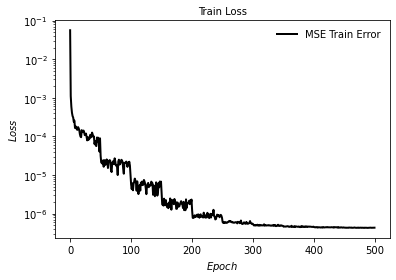

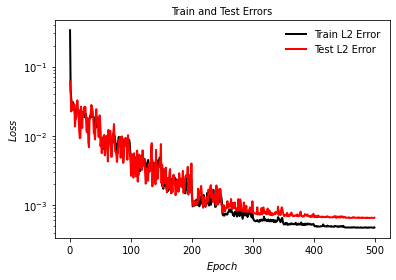

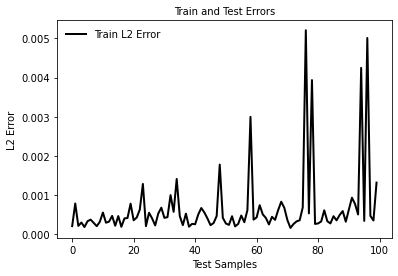

In [47]:
import matplotlib.gridspec as gridspec
ep,t, e_mse, trn_l2, tst_l2 = np.loadtxt("loss_err_fno.txt", delimiter=' ', usecols=(0, 1,2,3,4), unpack=True)
gs0 = gridspec.GridSpec(1,1)
ax = plt.subplot(gs0[:, :])
ax.semilogy(ep, e_mse, '-k', lw=2.0, label="MSE Train Error")
ax.set_xlabel('$Epoch$')
ax.set_ylabel('$Loss$')
ax.legend(frameon=False, loc = 'best')
ax.set_title('Train Loss', fontsize = 10)
plt.savefig("Train_Loss.png", dpi=300)

plt.show()
gs1 = gridspec.GridSpec(1,1)
ax1 = plt.subplot(gs1[:, :])
ax1.semilogy(ep, trn_l2, '-k', lw=2.0, label="Train L2 Error")
ax1.semilogy(ep, tst_l2, '-r', lw=2.0, label="Test L2 Error")

ax1.set_xlabel('$Epoch$')
ax1.set_ylabel('$Loss$')
ax1.legend(frameon=False, loc = 'best')
ax1.set_title('Train and Test Errors', fontsize = 10)
plt.savefig("Train_Test.png", dpi=300)

plt.show()

ba,e = np.loadtxt("eval_err.txt", delimiter=' ', usecols=(0, 1), unpack=True)
gs2 = gridspec.GridSpec(1,1)
ax2 = plt.subplot(gs1[:, :])
ax2.plot(ba, e, '-k', lw=2.0, label="Train L2 Error")

ax2.set_xlabel('Test Samples')
ax2.set_ylabel("L2 Error")
ax2.legend(frameon=False, loc = 'best')
ax2.set_title('Train and Test Errors', fontsize = 10)
plt.savefig("Error.png", dpi=300)

plt.show()


L2 Error is: 0.00020575149392243475


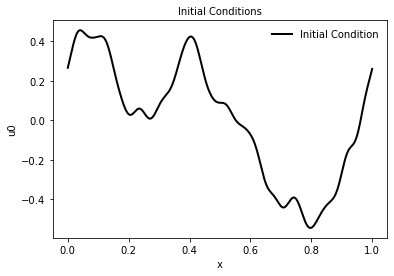

In [76]:
pred_u_plot = pred[0,:]
u_test_plot = y_test[0,:]
x_test_plot = x_test[0,:]
x_plot = np.linspace(0, 1, 1024)
err1 = np.linalg.norm(u_test_plot - pred_u_plot)
err2 = np.linalg.norm(u_test_plot)
err = err1/err2
print(f"L2 Error is: {err}")
gs = gridspec.GridSpec(1,1)
ax = plt.subplot(gs[:, :])
ax.plot(x_plot, pred_u_plot, '-k', lw=2.0, label="FNO Predicted")
ax.plot(x_plot, u_test_plot, '--b', lw=2.0, label="Actual Solution")
ax.set_xlabel('$x$')
ax.set_ylabel("u")
ax.legend(frameon=False, loc = 'best')
ax.set_title("Actual vs Predicetd $u$, T=1 with L2 Error = 0.0002", fontsize = 10)
plt.savefig("Solution", dpi=300)


gs = gridspec.GridSpec(1,1)
ax1 = plt.subplot(gs[:, :])
ax1.plot(x_plot, x_test_plot, '-k', lw=2.0, label="Initial Condition")
ax1.set_xlabel('x')
ax1.set_ylabel("u0")
ax1.legend(frameon=False, loc = 'best')
ax1.set_title("Initial Conditions", fontsize = 10)
plt.savefig("Ic_test", dpi=300)
plt.show()


tensor([0.1210, 0.1235, 0.1259,  ..., 0.1138, 0.1163, 0.1188])

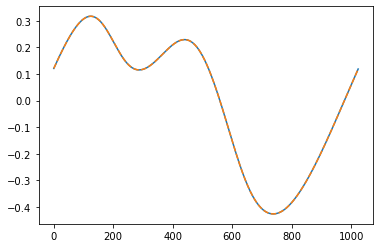

In [50]:
plt.plot(s1, "-")
plt.plot(s2,"--")